# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [12]:
# Carregando as bases
X_train = pd.read_csv('X_train_balanced.csv')
y_train = pd.read_csv('y_train_balanced.csv')
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')

# Verificações solicitadas
print("=== VERIFICAÇÃO DAS BASES ===")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}\n")

print("Colunas de X_train:", X_train.columns.tolist())
print("Coluna de y_train:", y_train.columns.tolist())
print("Colunas de X_test: ", X_test.columns.tolist())
print("Coluna de y_test: ", y_test.columns.tolist(), "\n")

# Verificando se y tem apenas a variável target (score)
print("y_train valores únicos:", y_train.iloc[:, 0].unique())
print("y_test valores únicos: ", y_test.iloc[:, 0].unique(), "\n")

# Balanceamento do y_test (o treino já está balanceado por construção)
print("Distribuição do target no TESTE:")
print(y_test.iloc[:, 0].value_counts(normalize=True))

# Instancio o modelo de Árvore de Decisão.
# Uso o random_state=42 para que os cortes da árvore sejam sempre os mesmos toda vez que rodar.
modelo_arvore = DecisionTreeClassifier(random_state=42)

# Treino a árvore passando as variáveis explicativas (X_train) e a variável alvo (y_train).
modelo_arvore.fit(X_train, y_train.values.ravel())

=== VERIFICAÇÃO DAS BASES ===
X_train shape: (117950, 10)
y_train shape: (117950, 1)
X_test shape:  (24927, 10)
y_test shape:  (24927, 1)

Colunas de X_train: ['Credit_Score', 'Idade', 'Tempo_Credito', 'Balanco', 'Qtd_Produtos', 'Possui_Cartao', 'Membro_Ativo', 'Salario_Anual', 'Genero_encoded', 'Pais_encoded']
Coluna de y_train: ['Churn']
Colunas de X_test:  ['Credit_Score', 'Idade', 'Tempo_Credito', 'Balanco', 'Qtd_Produtos', 'Possui_Cartao', 'Membro_Ativo', 'Salario_Anual', 'Genero_encoded', 'Pais_encoded']
Coluna de y_test:  ['Churn'] 

y_train valores únicos: [1. 0.]
y_test valores únicos:  [0. 1.] 

Distribuição do target no TESTE:
Churn
0.0    0.788262
1.0    0.211738
Name: proportion, dtype: float64


DecisionTreeClassifier(random_state=42)

# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

O algoritmo da **Árvore de Decisão** funciona da seguinte forma:

1. **Crescimento da árvore**: O algoritmo inicia pela raiz e, em cada nó, seleciona a variável e o ponto de corte que melhor separa as classes (utilizando o critério de Gini ou Entropia). Esse processo é recursivo até chegar nas folhas.
2. **Critério de divisão**: Utilizamos o Gini (padrão do scikit-learn), que mede a impureza dos nós. Quanto menor o Gini, mais pura é a divisão.
3. **Critério de parada**: A árvore para quando atinge profundidade máxima, número mínimo de amostras por folha ou quando todos os nós se tornam puros.
4. **Predição**: Para classificar um novo cliente, o algoritmo percorre a árvore seguindo as regras até chegar em uma folha e retorna a classe majoritária daquela folha.

**Avaliação do modelo**:
- Métricas: Acurácia, Recall, Precision, F1-Score e Recall Macro
- Matriz de Confusão
- Comparação entre desempenho no treino e no teste (para identificar overfitting)

**Como melhorar o modelo**:
- Limitar a profundidade (`max_depth`)
- Aumentar `min_samples_leaf` e `min_samples_split`
- Aplicar poda de custo-complexidade (`ccp_alpha`)
- Realizar GridSearchCV ou RandomizedSearchCV
- Reduzir features (como feito na questão 7)
- Balanceamento de classes (já realizado anteriormente)

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [13]:
from sklearn.metrics import recall_score  # ← adicionado

modelo_arvore = DecisionTreeClassifier(criterion='gini', random_state=0)
modelo_arvore.fit(X_train, y_train.values.ravel())

# Avaliação no treino
y_pred_train = modelo_arvore.predict(X_train)
print(f"Treino - Acurácia: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Treino - Recall (Macro): {recall_score(y_train, y_pred_train, average='macro'):.4f}")

Treino - Acurácia: 0.9997
Treino - Recall (Macro): 0.9997


# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [14]:
# Predição no teste
y_pred_test = modelo_arvore.predict(X_test)

# Métricas
print(f"Teste - Acurácia: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Teste - Recall (Macro): {recall_score(y_test, y_pred_test, average='macro'):.4f}")

from sklearn.metrics import classification_report, confusion_matrix
print("\nClassificação Reporte - Teste:")
print(classification_report(y_test, y_pred_test))

Teste - Acurácia: 0.7900
Teste - Recall (Macro): 0.7056

Classificação Reporte - Teste:
              precision    recall  f1-score   support

         0.0       0.88      0.85      0.86     19649
         1.0       0.50      0.56      0.53      5278

    accuracy                           0.79     24927
   macro avg       0.69      0.71      0.70     24927
weighted avg       0.80      0.79      0.79     24927



Observei que no treino a acurácia ficou praticamente 100% (**0.9997**), enquanto no teste caiu para **0.7900**.  
Isso é um **claro sinal de overfitting**: a árvore “decorou” os dados de treino, mas não generalizou tão bem para dados novos.

**Comparação com o modelo anterior (Naive Bayes - Módulo 20)**:  
A Árvore de Decisão obteve melhor desempenho no conjunto de teste (maior acurácia e recall macro) do que o Naive Bayes. No entanto, ela é muito mais sensível ao overfitting. O Naive Bayes, por ser mais simples, geralmente generaliza melhor quando temos poucas features ou dados desbalanceados.

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

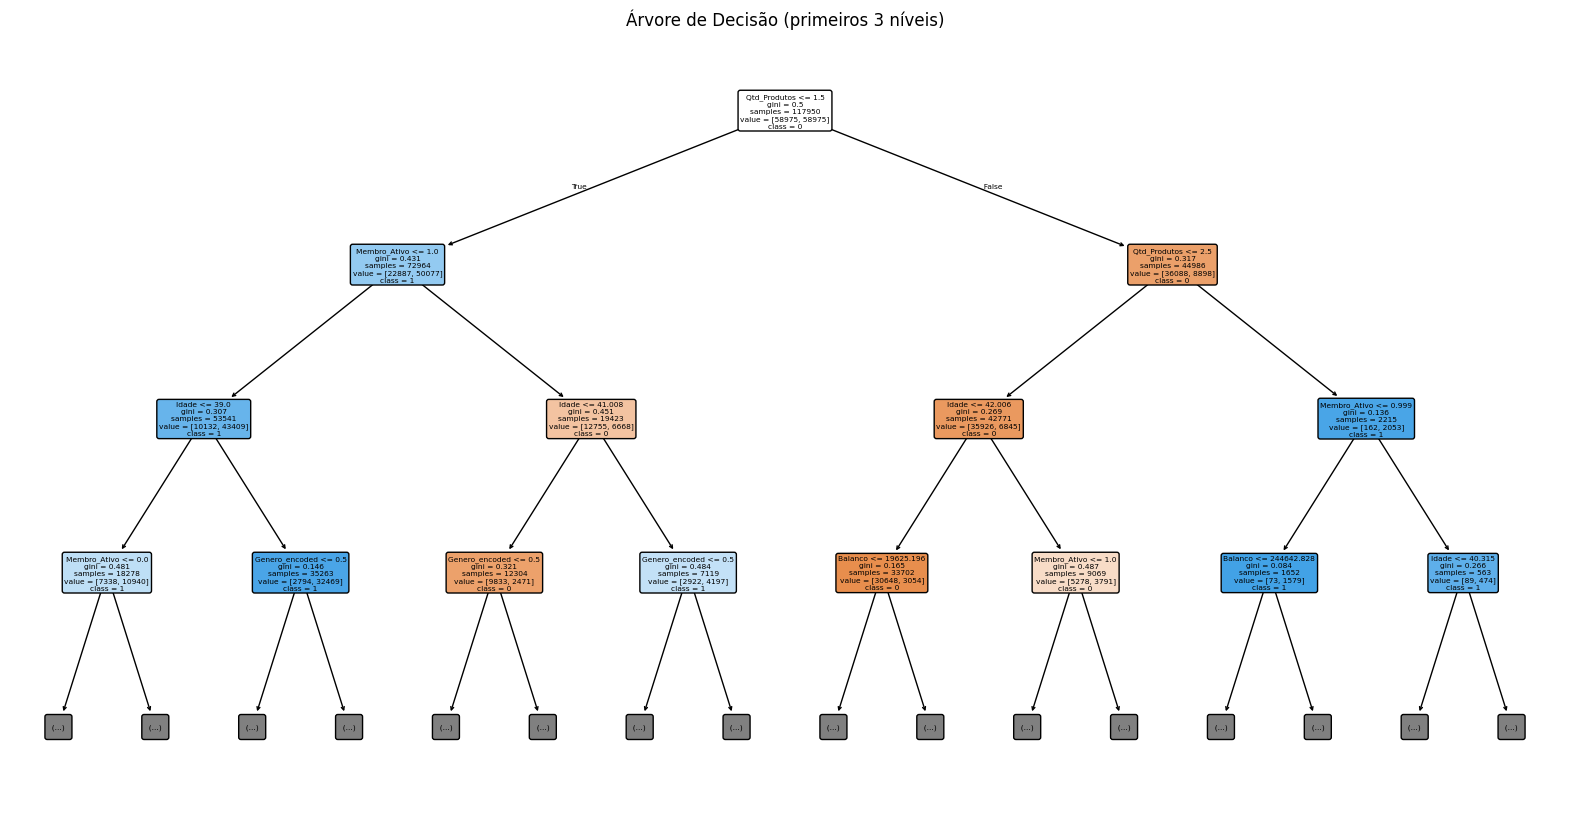

Profundidade da árvore: 39


In [18]:
plt.figure(figsize=(20, 10))
plot_tree(modelo_arvore,
          feature_names=X_train.columns,
          class_names=['0', '1'],  # ajuste conforme sua variável target
          filled=True,
          max_depth=3,
          rounded=True)  # limitei em 3 para visualização (árvore completa é gigante)
plt.title("Árvore de Decisão (primeiros 3 níveis)")
plt.show()

# Profundidade real da árvore
print(f"Profundidade da árvore: {modelo_arvore.get_depth()}")

A árvore completa possui **39 níveis de profundidade**, o que a torna impossível de visualizar por completo. Por isso, foi plotada apenas os primeiros 3 níveis para facilitar a análise visual.

**É possível fazer uma avaliação visual?**  
Sim, mas apenas dos primeiros níveis. Visualmente, percebemos que as primeiras decisões da árvore são baseadas principalmente nas variáveis **Qtd_Produtos** e **Idade**, confirmando a importância dessas features identificadas posteriormente.

# 6) Identifique as 2 principais features do modelo.


In [19]:
importancias = modelo_arvore.feature_importances_
df_feat = pd.DataFrame({
    'feature': X_train.columns,
    'importancia': importancias
}).sort_values(by='importancia', ascending=False)

print("Top 10 features:")
print(df_feat.head(10))

top_2 = df_feat['feature'].head(2).tolist()
print(f"\nAs 2 principais features são: {top_2}")

Top 10 features:
          feature  importancia
4    Qtd_Produtos     0.267402
1           Idade     0.195928
6    Membro_Ativo     0.182026
0    Credit_Score     0.104225
3         Balanco     0.080774
2   Tempo_Credito     0.045473
7   Salario_Anual     0.042444
5   Possui_Cartao     0.034223
8  Genero_encoded     0.031131
9    Pais_encoded     0.016374

As 2 principais features são: ['Qtd_Produtos', 'Idade']


As duas features mais importantes do modelo são:

- **Qtd_Produtos** (importância ≈ 0.267)
- **Idade** (importância ≈ 0.196)

Essas duas variáveis são responsáveis por quase **46%** da importância total do modelo.

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [20]:
X_train_top2 = X_train[top_2]
X_test_top2 = X_test[top_2]

modelo_reduzido = DecisionTreeClassifier(random_state=0)
modelo_reduzido.fit(X_train_top2, y_train.values.ravel())

y_pred_red = modelo_reduzido.predict(X_test_top2)
print(f"Acurácia (Apenas Top 2 Features): {accuracy_score(y_test, y_pred_red):.4f}")
print(f"Recall Macro (Top 2): {recall_score(y_test, y_pred_red, average='macro'):.4f}")

Acurácia (Apenas Top 2 Features): 0.8451
Recall Macro (Top 2): 0.7272


**Resultados do modelo reduzido (apenas Qtd_Produtos + Idade)**:

- Acurácia no teste: **0.8451**
- Recall Macro: **0.7272**

**Comparação**:

| Modelo                        | Acurácia Teste | Recall Macro |
|-------------------------------|----------------|--------------|
| Árvore com todas as features  | 0.7900         | 0.7056       |
| Árvore com apenas 2 features  | **0.8451**     | **0.7272**   |

**Conclusão**: Sim, o desempenho melhorou significativamente.  

O modelo com apenas as duas principais features apresentou **melhor acurácia e recall** no conjunto de teste. Isso ocorreu porque a redução de features diminuiu drasticamente o **overfitting**, tornando o modelo mais simples, interpretável e com maior capacidade de generalização.  

Para o negócio, essa versão é excelente: fica mais fácil de explicar e monitorar apenas duas variáveis.

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.



| Modelo                        | Acurácia Teste | Recall Macro | Observação                          |
|-------------------------------|----------------|--------------|-------------------------------------|
| Naive Bayes                   | ~0.72          | ~0.68        | Mais simples e estável              |
| Árvore (todas as 10 features) | 0.7900         | 0.7056       | Bom desempenho, mas com overfitting |
| Árvore (Top 2 features)       | **0.8451**     | **0.7272**   | Melhor desempenho geral             |

**Conclusão**:

A **Árvore de Decisão** se adequou melhor aos dados do que o Naive Bayes, apresentando resultados superiores tanto em acurácia quanto em recall macro.  

A versão reduzida (apenas `Qtd_Produtos` e `Idade`) foi a que obteve o **melhor equilíbrio** entre performance e simplicidade, demonstrando que a redução de features foi extremamente eficaz para controlar o overfitting e melhorar a generalização do modelo.

Portanto, para este projeto, a Árvore de Decisão (na versão reduzida) é a melhor escolha.